In [2]:
from datasets import load_dataset
import torch
import unicodedata
from pypinyin import lazy_pinyin
import re
from torchaudio.pipelines import MMS_FA as bundle
from typing import List
from transformers import Wav2Vec2Model, Wav2Vec2Processor
import numpy as np
from tqdm.auto import tqdm
import gc
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import umap
import json

In [3]:
dataset = load_dataset("CAiRE/ASCEND")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00003.parquet:   0%|          | 0.00/317M [00:00<?, ?B/s]

main/train-00001-of-00003.parquet:   0%|          | 0.00/367M [00:00<?, ?B/s]

main/train-00002-of-00003.parquet:   0%|          | 0.00/328M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

main/validation-00000-of-00001.parquet:   0%|          | 0.00/107M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9869 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1315 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1130 [00:00<?, ? examples/s]

cuda


In [4]:
def is_chinese(char):
    return 'CJK UNIFIED IDEOGRAPH' in unicodedata.name(char, '')

def is_english(char):
    return char.isascii() and char.isalpha()

def tokenize_with_languages(text):
    tokens = []
    token_languages = []
    current = ""
    for char in text:
        if is_chinese(char):
            if current:
                tokens.append(current)
                token_languages.append("en")
                current=""
            tokens.append(char)
            token_languages.append("zh")
        elif is_english(char):
            current += char
        elif char==" " and current:
            tokens.append(current)
            token_languages.append("en")
            current=""
    if current:
        tokens.append(current)
        token_languages.append("en")
    return tokens, token_languages

In [5]:
def romanize(text):
    return " ".join(lazy_pinyin(text))

In [6]:
def normalize(text):
    text = text.lower()
    text = text.replace("’", "'")
    text = re.sub("([^a-z' ])", " ", text)
    text = re.sub(' +', ' ', text)
    return text.strip()

In [7]:
model = bundle.get_model()
model.to(device)

tokenizer = bundle.get_tokenizer()
aligner = bundle.get_aligner()

Downloading: "https://dl.fbaipublicfiles.com/mms/torchaudio/ctc_alignment_mling_uroman/model.pt" to /root/.cache/torch/hub/checkpoints/model.pt


100%|██████████| 1.18G/1.18G [00:03<00:00, 344MB/s]


In [8]:
def compute_alignments(waveform: torch.Tensor, transcript: List[str]):
    with torch.inference_mode():
        emission, _ = model(waveform.to(device))
        token_spans = aligner(emission[0], tokenizer(transcript))
    return emission, token_spans

In [9]:
def get_mms_fa_interval(token_language, waveform, spans, num_frames, sample_rate=bundle.sample_rate):
    ratio = waveform.size(1) / num_frames
    x0 = int(ratio * spans[0].start)
    x1 = int(ratio * spans[-1].end)
    return (token_language, round(x0 / sample_rate, 3), round(x1 / sample_rate, 3))

In [10]:
sample = dataset["train"][2]

text_raw = sample["transcription"]
tokens, token_languages = tokenize_with_languages(text_raw)
text_romanized = romanize(" ".join(tokens))
text_normalized = normalize(text_romanized)
transcript = text_normalized.split()

waveform = torch.tensor(sample["audio"]["array"], dtype=torch.float32).unsqueeze(0)
sample_rate = sample["audio"]["sampling_rate"]

emission, token_spans = compute_alignments(waveform, transcript)
num_frames = emission.size(1)

mms_fa_intervals = []
for i in range(len(transcript)):
    mms_fa_intervals.append(get_mms_fa_interval(token_languages[i], waveform, token_spans[i], num_frames))

print(mms_fa_intervals)

[('zh', 0.06, 0.08), ('zh', 0.443, 0.543), ('zh', 0.624, 0.704), ('zh', 0.744, 0.905), ('zh', 0.946, 1.127), ('en', 1.288, 1.529), ('en', 1.549, 1.63), ('en', 1.69, 1.871), ('en', 1.932, 2.072), ('zh', 2.374, 2.394)]


In [11]:
wav2vec2_processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
wav2vec2_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
wav2vec2_model.eval()

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [12]:
inputs = wav2vec2_processor(
    waveform.squeeze(0).numpy(),
    sampling_rate=sample_rate,
    return_tensors="pt"
)

input_values = inputs.input_values.to(device)

with torch.inference_mode():
    outputs = wav2vec2_model(
        input_values,
        output_hidden_states=True
    )

hidden_states = outputs.hidden_states

print("Number of hidden states:", len(hidden_states))
print("Hidden state shape:", hidden_states[0].shape)

Number of hidden states: 13
Hidden state shape: torch.Size([1, 165, 768])


In [13]:
print("MMS_FA: ")
print("Number of frames:", num_frames)
print("Samples per frame:", round(waveform.size(1) / num_frames, 3))
print("Audio duration (sec):", waveform.size(1) / bundle.sample_rate)
print("Seconds per frame:", round(((waveform.size(1) / bundle.sample_rate) / num_frames), 3))

wv_num_frames = hidden_states[0].size(1)
samples_per_frame = input_values.size(1) / wv_num_frames
wv_duration = input_values.size(1) / sample_rate
seconds_per_frame = samples_per_frame / sample_rate

print("\nWav2Vec2: ")
print("Number of frames:", wv_num_frames)
print("Samples per frame:", round(samples_per_frame, 3))
print("Audio duration (sec):", wv_duration)
print("Seconds per frame:", round(seconds_per_frame, 3))

print("\nAudio duration (sec):", sample["duration"])

MMS_FA: 
Number of frames: 165
Samples per frame: 321.939
Audio duration (sec): 3.32
Seconds per frame: 0.02

Wav2Vec2: 
Number of frames: 165
Samples per frame: 321.939
Audio duration (sec): 3.32
Seconds per frame: 0.02

Audio duration (sec): 3.319999933242798


In [14]:
def get_frame_language(frame_time, mms_fa_intervals):
    for language, start, end in mms_fa_intervals:
        if start <= frame_time <= end:
            return language
    return None

In [15]:
frame_times = np.arange(wv_num_frames) * seconds_per_frame

frame_labels = [
    get_frame_language(frame_time, mms_fa_intervals)
    for frame_time in frame_times
]

In [16]:
features = hidden_states[0].squeeze(0)

valid_indices = [
    i for i, label in enumerate(frame_labels)
    if label is not None
]

X = features[valid_indices]
y = np.array([frame_labels[i] for i in valid_indices])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([57, 768])
y shape: (57,)


In [17]:
def get_language_ground_truth(sample):
    
    text_raw = sample["transcription"]
    tokens, token_languages = tokenize_with_languages(text_raw)
    text_romanized = romanize(" ".join(tokens))
    text_normalized = normalize(text_romanized)
    transcript = text_normalized.split()
    if len(transcript) != len(token_languages):
        raise ValueError(f"Token mismatch: {len(transcript)} transcript tokens vs {len(token_languages)} language labels")
    
    waveform = torch.tensor(sample["audio"]["array"], dtype=torch.float32).unsqueeze(0)
    sample_rate = sample["audio"]["sampling_rate"]
    if sample_rate != bundle.sample_rate:
        raise ValueError(f"Expected sample rate {bundle.sample_rate} got {sample_rate}")

    emission, token_spans = compute_alignments(waveform, transcript)
    num_frames = emission.size(1)
    
    mms_fa_intervals = []
    for i in range(len(transcript)):
        mms_fa_intervals.append(get_mms_fa_interval(token_languages[i], waveform, token_spans[i], num_frames))
    
    inputs = wav2vec2_processor(
        waveform.squeeze(0).numpy(),
        sampling_rate=sample_rate,
        return_tensors="pt"
    )
        
    input_values = inputs.input_values.to(device)
    
    with torch.inference_mode():
        outputs = wav2vec2_model(
            input_values,
            output_hidden_states=False
        )

    wv_num_frames = outputs.last_hidden_state.size(1)
    samples_per_frame = input_values.size(1) / wv_num_frames
    seconds_per_frame = samples_per_frame / sample_rate
    
    frame_times = np.arange(wv_num_frames) * seconds_per_frame
    
    frame_labels = [
        get_frame_language(frame_time, mms_fa_intervals)
        for frame_time in frame_times
    ]
    
    valid_indices = [
        i for i, label in enumerate(frame_labels)
        if label is not None
    ]

    y = np.array([frame_labels[i] for i in valid_indices])

    labeled_frame_times = frame_times[valid_indices]
    
    return y, labeled_frame_times, valid_indices

In [18]:
ground_truth = {}
failures = []

for split in dataset.keys():

    ground_truth[split] = []

    for idx, sample in enumerate(tqdm(dataset[split], desc=split)):

        if "[UNK]" in sample["transcription"]:
            continue

        try:
            y, frame_times, valid_indices = get_language_ground_truth(sample)

            ground_truth[split].append({
                "index": idx,
                "y": y,
                "frame_times": frame_times, 
                "valid_indices": valid_indices
            })

        except Exception as e:
            failures.append({
                "split": split,
                "index": idx,
                "error": str(e)
            })

train:   0%|          | 0/9869 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

test:   0%|          | 0/1315 [00:00<?, ?it/s]

validation:   0%|          | 0/1130 [00:00<?, ?it/s]

In [19]:
def extract_layer_features(sample, layer, valid_indices):
    waveform = torch.tensor(sample["audio"]["array"], dtype=torch.float32).unsqueeze(0)
    sample_rate = sample["audio"]["sampling_rate"]

    inputs = wav2vec2_processor(
        waveform.squeeze(0).numpy(),
        sampling_rate=sample_rate,
        return_tensors="pt"
    )
        
    input_values = inputs.input_values.to(device)
    
    with torch.inference_mode():
        outputs = wav2vec2_model(
            input_values,
            output_hidden_states=True
        )
    
    hidden_states = outputs.hidden_states
    
    features = hidden_states[layer].squeeze(0)

    X = features[valid_indices].cpu().numpy()

    return X

In [20]:
def evaluate_layer(layer, dataset, ground_truth):
    print("Layer: ", layer)
    
    X = {}
    y = {}

    for split in dataset.keys():
        
        X[split] = []
        y[split] = []

        for gt in ground_truth[split]:
            
            idx = gt["index"]
            sample = dataset[split][idx]
            valid_indices = gt["valid_indices"]
            y_sample = gt["y"]
            
            X_sample = extract_layer_features(sample, layer, valid_indices)
            if X_sample.shape[0] != len(y_sample):
                raise ValueError(f"X and y shape mismatch in {split}, index {idx}")
                
            X[split].append(X_sample)
            y[split].append(y_sample)

        X[split] = np.concatenate(X[split], axis=0)
        y[split] = np.concatenate(y[split], axis=0)

        print(f"{split}: X = {X[split].shape}, y = {y[split].shape}")

    X_train = X["train"]
    y_train = y["train"]

    # X_val = X["validation"]
    # y_val = y["validation"]

    X_test = X["test"]
    y_test = y["test"]

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )

    model.fit(X_train, y_train)
    print("Number of iterations:", model[-1].n_iter_)

    en_index = list(model[-1].classes_).index("en")

    #val_prob = model.predict_proba(X_val)[:, en_index]

    test_prob = model.predict_proba(X_test)[:, en_index]

    y_test_binary = (y_test == "en").astype(int)

    test_metrics = {
        "roc_auc": float(roc_auc_score(y_test_binary, test_prob)),
        "ap": float(average_precision_score(y_test_binary, test_prob)),
        "log_loss": float(log_loss(y_test_binary, test_prob)),
        "brier_score": float(brier_score_loss(y_test_binary, test_prob))
    }

    print("\nTest metrics:")
    for metric, value in test_metrics.items():
        print(f"{metric}: {value:.3f}")

    prob_true, prob_pred = calibration_curve(
        y_test_binary,
        test_prob,
        n_bins=10
    )
    
    plt.figure(figsize=(6, 6))
    
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(prob_pred, prob_true, marker="o")
    
    plt.xlabel("Mean predicted probability of English")
    plt.ylabel("Observed fraction of English frames")
    plt.title(f"Calibration Curve — Layer {layer}")
    
    plt.show()

    max_umap_samples = 10000

    if len(X_test) > max_umap_samples:

        rng = np.random.default_rng(42)

        umap_indices = rng.choice(
            len(X_test),
            size=max_umap_samples,
            replace=False
        )

        X_umap = X_test[umap_indices]
        y_umap = y_test[umap_indices]

    else:

        X_umap = X_test
        y_umap = y_test

    reducer = umap.UMAP(
        n_components=2,
        random_state=42
    )

    umap_coordinates = reducer.fit_transform(X_umap)

    plt.figure(figsize=(8, 6))
    
    plt.scatter(
        umap_coordinates[:, 0],
        umap_coordinates[:, 1],
        c=(y_umap == "en"),
        s=5
    )
    
    plt.title(f"UMAP - Layer {layer}")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()

    results = {
        "layer": layer,
        "metrics": test_metrics
    }
    
    return results

In [21]:
def evaluate_all_layers(dataset, ground_truth):
    
    results = {}
    
    num_layers = wav2vec2_model.config.num_hidden_layers + 1
    
    for layer in range(num_layers):
        result = evaluate_layer(layer, dataset, ground_truth)
        results[layer] = result

    return results

Layer:  0
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [114]

Test metrics:
roc_auc: 0.745
ap: 0.619
log_loss: 0.561
brier_score: 0.189


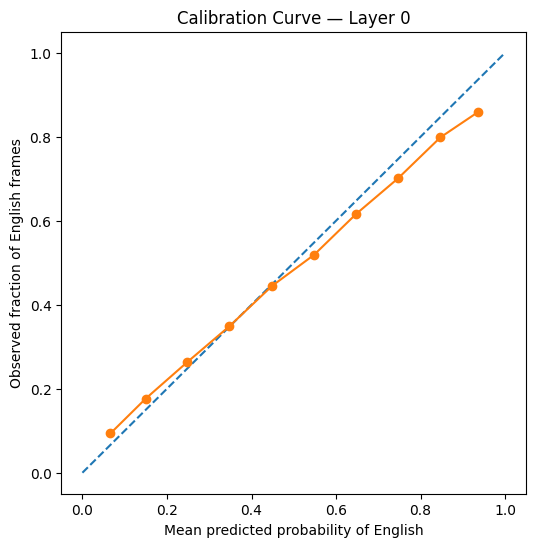

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


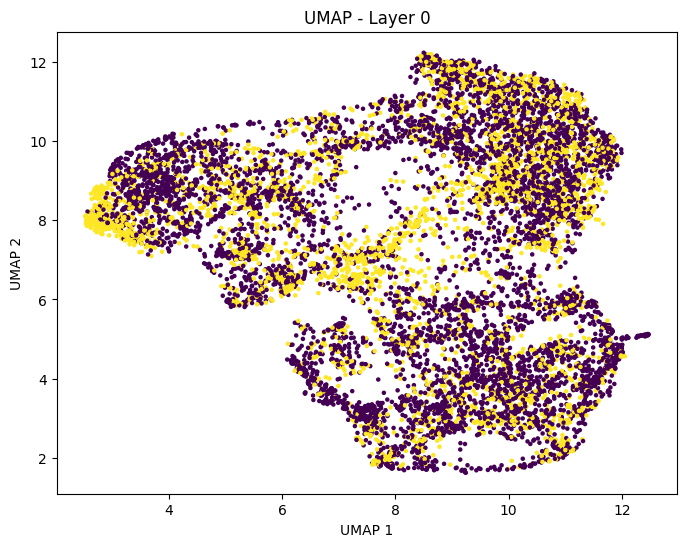

Layer:  1
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [95]

Test metrics:
roc_auc: 0.767
ap: 0.663
log_loss: 0.540
brier_score: 0.181


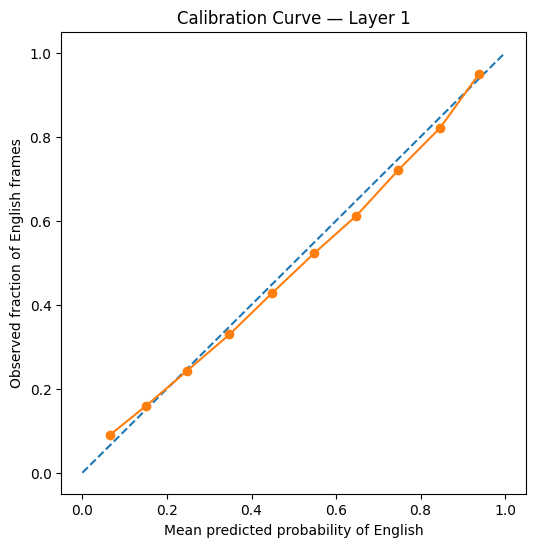

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


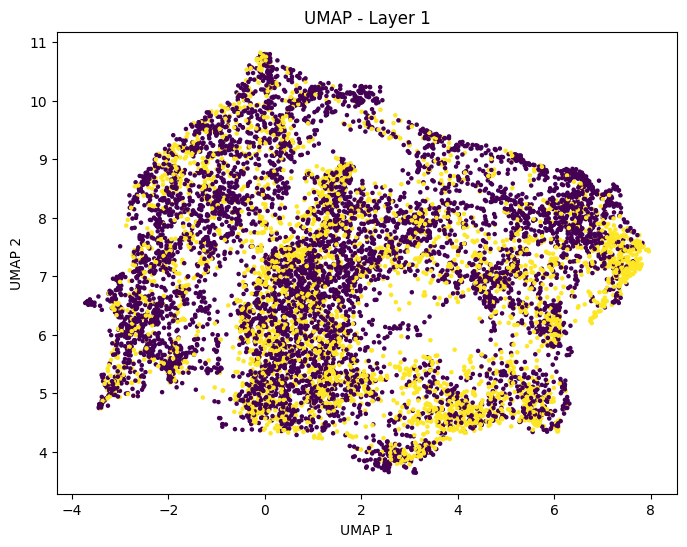

Layer:  2
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [74]

Test metrics:
roc_auc: 0.785
ap: 0.686
log_loss: 0.526
brier_score: 0.175


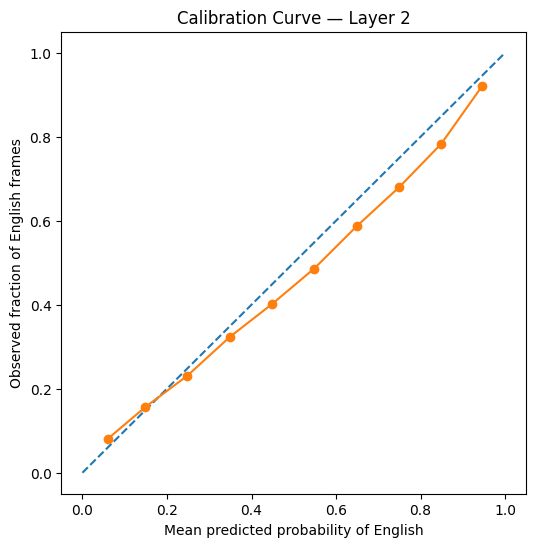

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


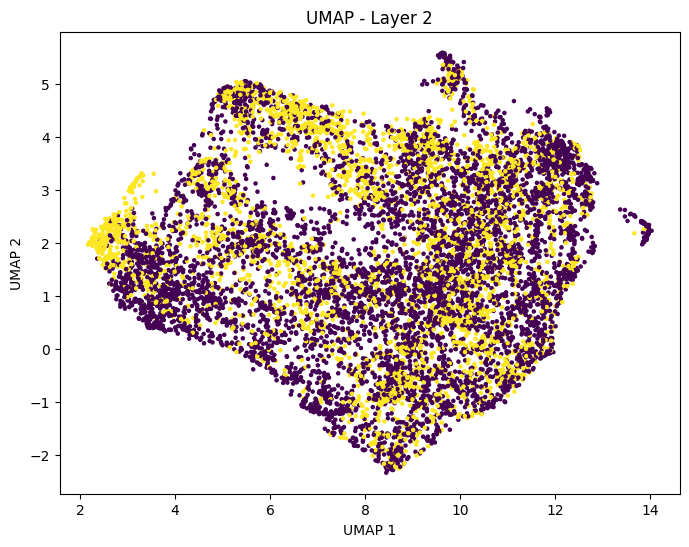

Layer:  3
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [50]

Test metrics:
roc_auc: 0.798
ap: 0.710
log_loss: 0.514
brier_score: 0.170


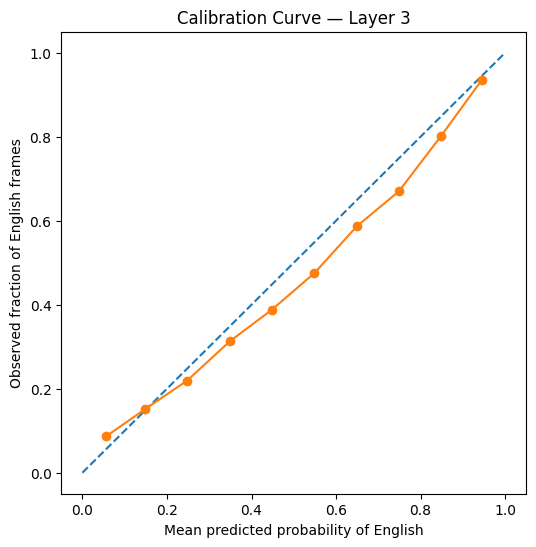

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


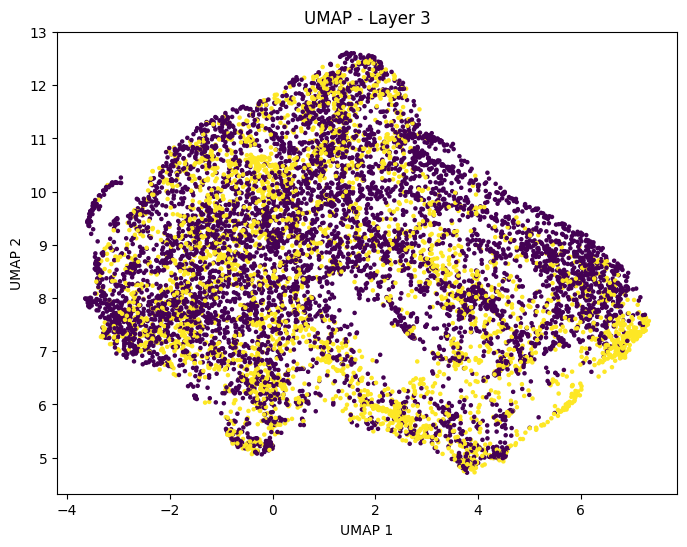

Layer:  4
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [75]

Test metrics:
roc_auc: 0.835
ap: 0.764
log_loss: 0.471
brier_score: 0.153


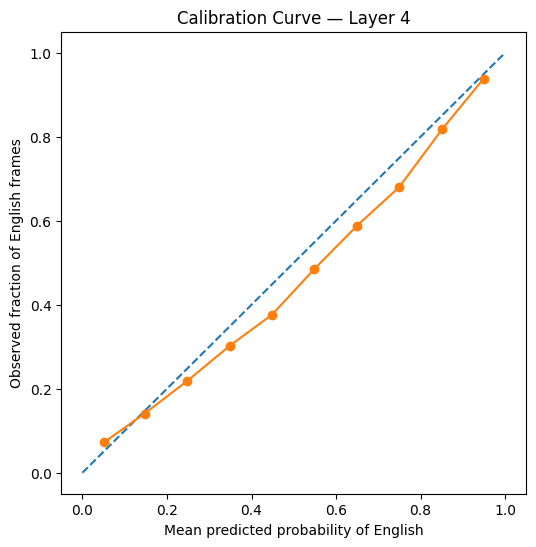

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


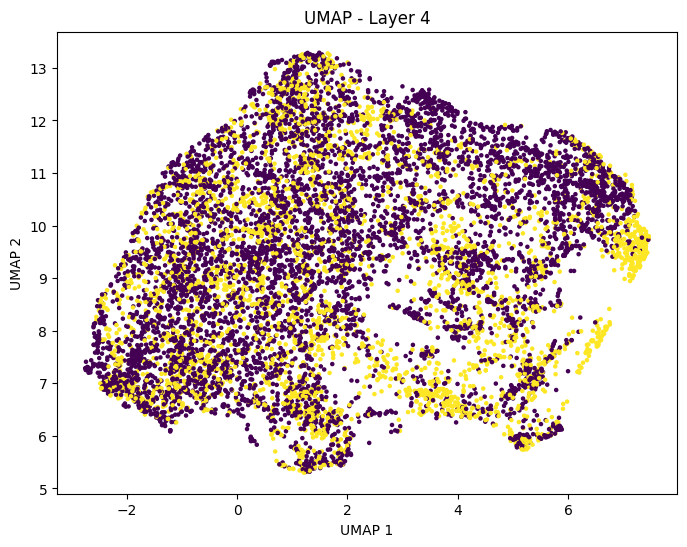

Layer:  5
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [63]

Test metrics:
roc_auc: 0.870
ap: 0.811
log_loss: 0.426
brier_score: 0.136


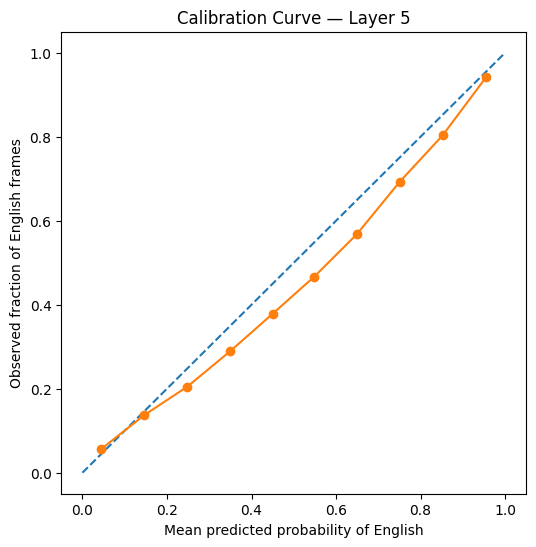

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


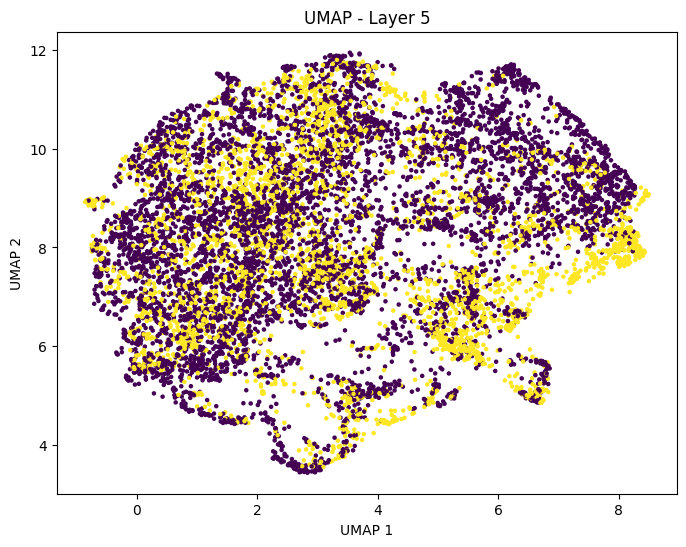

Layer:  6
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [54]

Test metrics:
roc_auc: 0.883
ap: 0.829
log_loss: 0.406
brier_score: 0.129


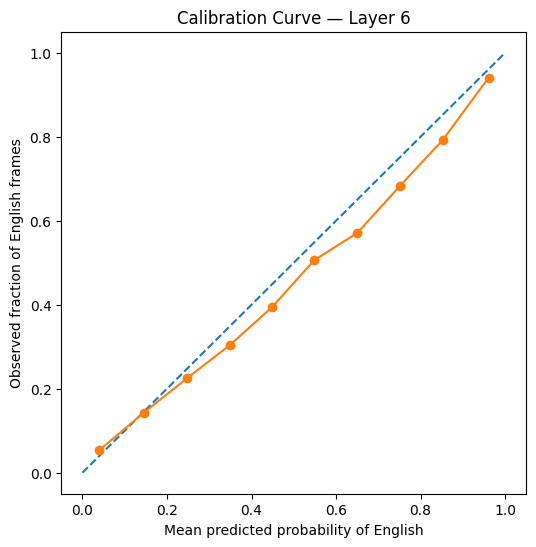

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


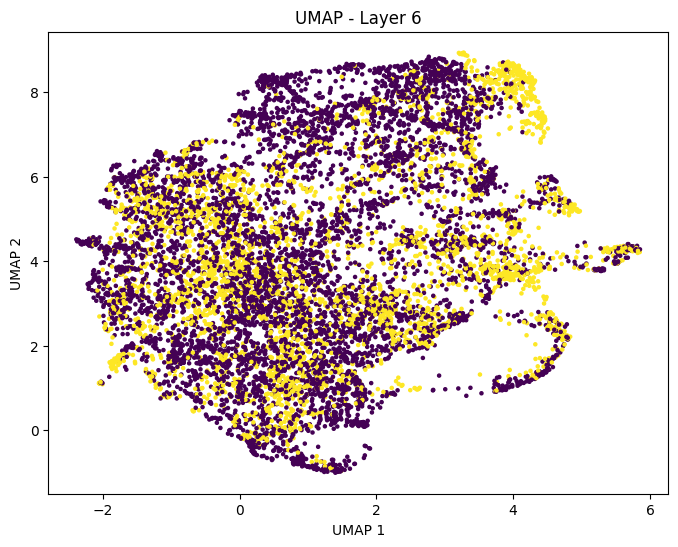

Layer:  7
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [38]

Test metrics:
roc_auc: 0.891
ap: 0.842
log_loss: 0.392
brier_score: 0.122


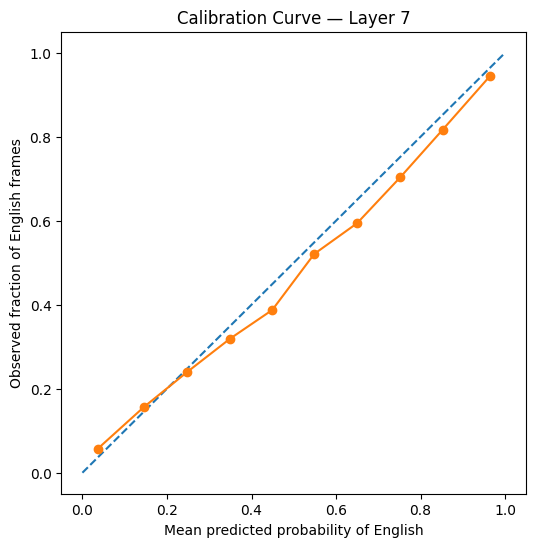

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


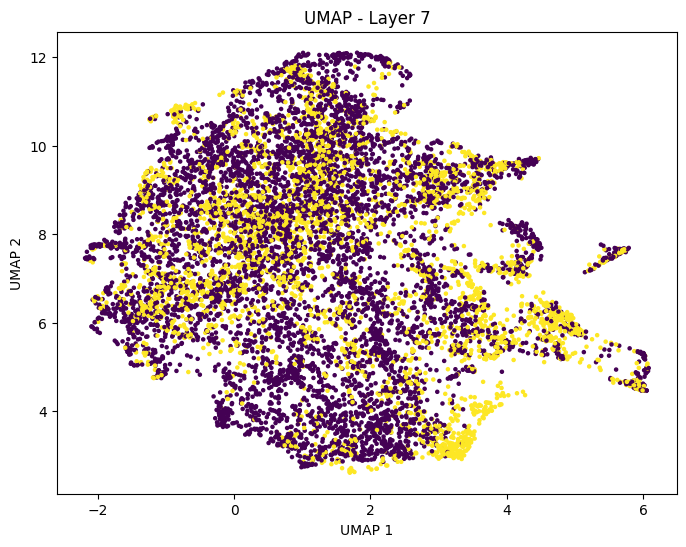

Layer:  8
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [48]

Test metrics:
roc_auc: 0.895
ap: 0.850
log_loss: 0.386
brier_score: 0.119


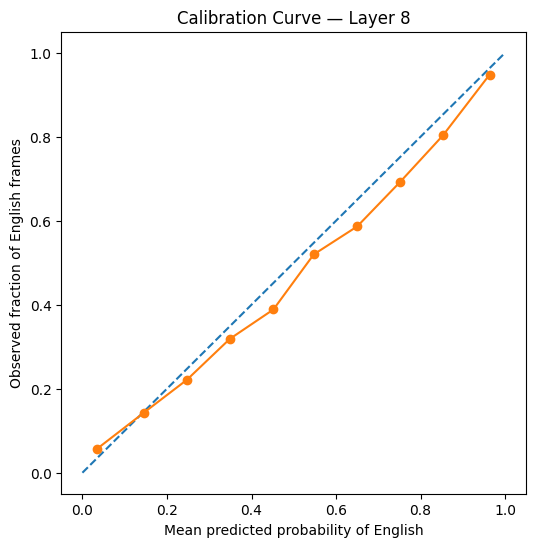

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


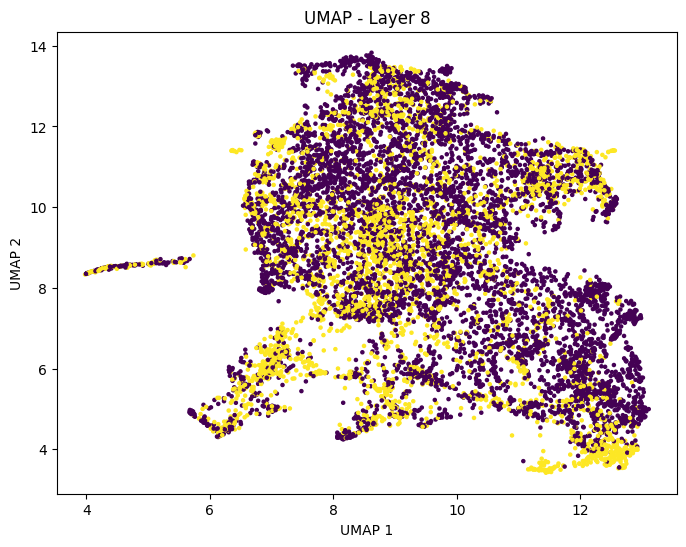

Layer:  9
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [67]

Test metrics:
roc_auc: 0.891
ap: 0.844
log_loss: 0.392
brier_score: 0.123


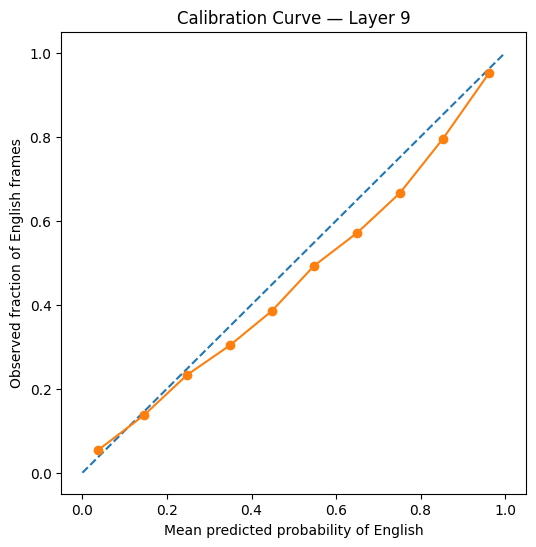

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


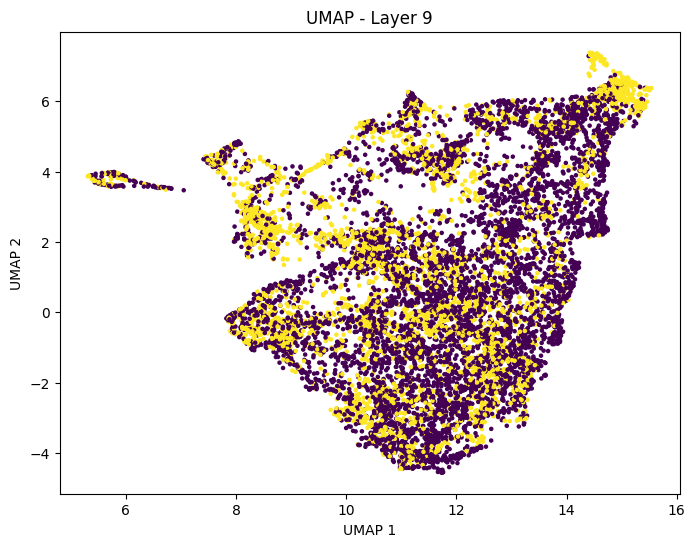

Layer:  10
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [85]

Test metrics:
roc_auc: 0.877
ap: 0.825
log_loss: 0.420
brier_score: 0.133


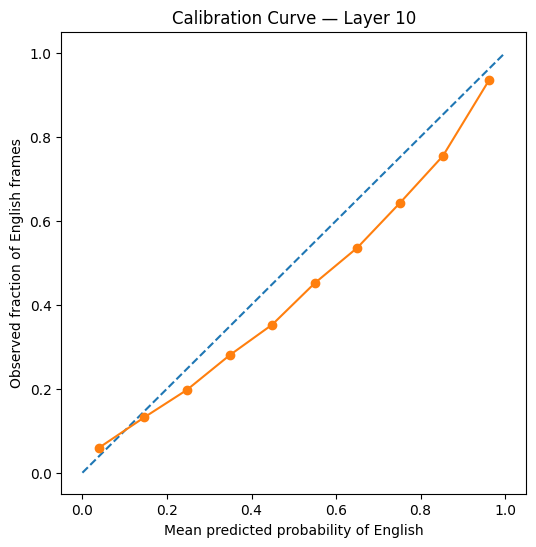

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


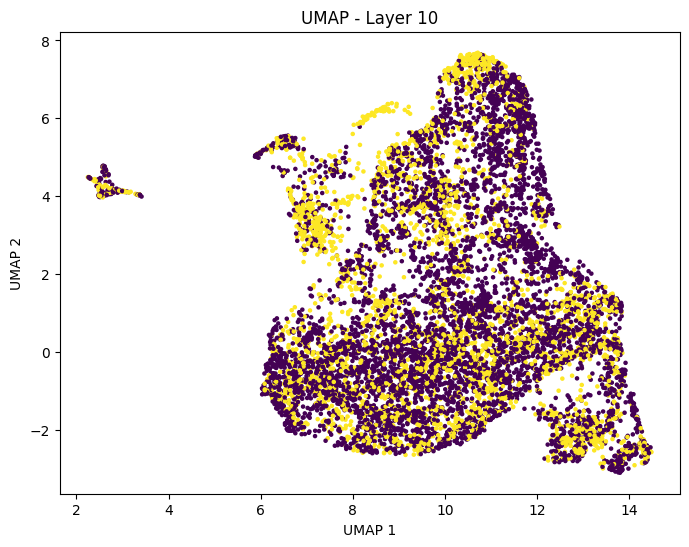

Layer:  11
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [242]

Test metrics:
roc_auc: 0.824
ap: 0.732
log_loss: 0.549
brier_score: 0.168


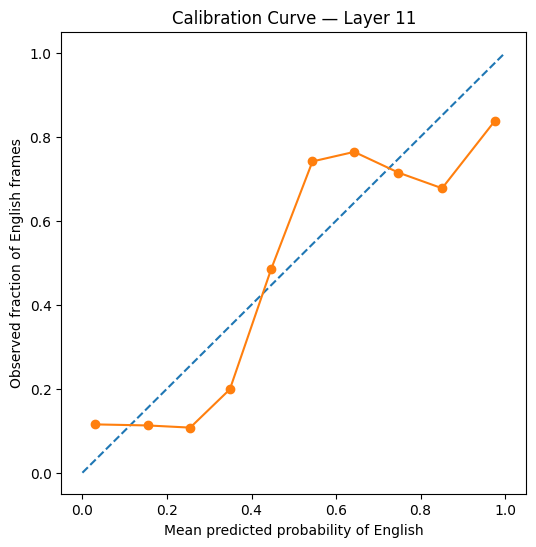

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


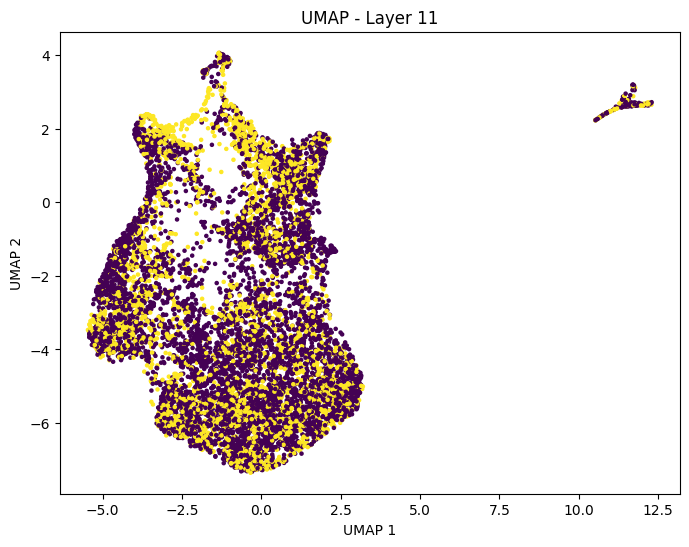

Layer:  12
train: X = (756350, 768), y = (756350,)
test: X = (79318, 768), y = (79318,)
validation: X = (76804, 768), y = (76804,)
Number of iterations: [203]

Test metrics:
roc_auc: 0.855
ap: 0.790
log_loss: 0.453
brier_score: 0.141


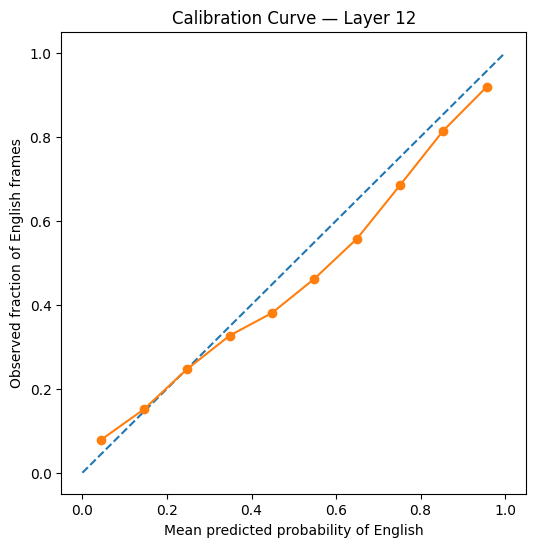

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


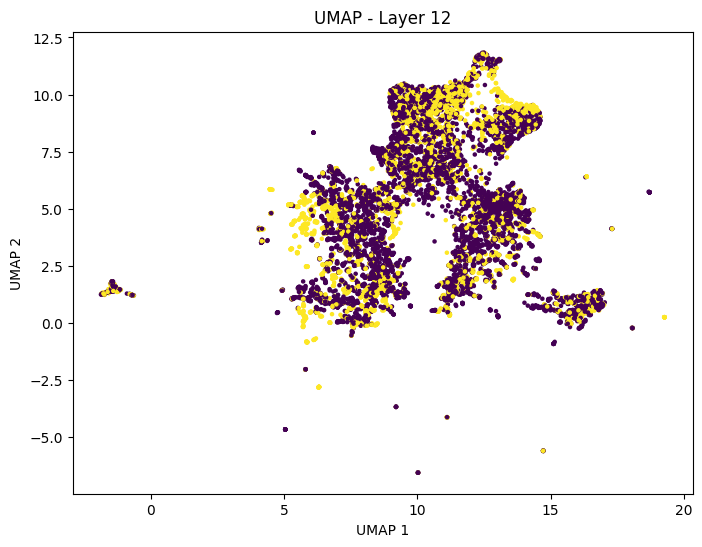

In [22]:
results = evaluate_all_layers(dataset, ground_truth)

In [ ]:
with open("outputs/fs1_language_identity_results.json", "w") as f:
    json.dump(results, f, indent=2)